<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/02_deep_learning_foundations/15_early_stopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Early Stopping

Training a neural network for too many epochs can cause overfitting.

Early Stopping is a technique that monitors the model's performance on the validation dataset and automatically stops training when the performance stops improving.

Instead of training for a fixed number of epochs, the model trains only as long as it continues to learn useful patterns.

This helps save training time and improves model generalization.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
X = np.array([
    [0,0],[0,1],[1,0],[1,1],
    [0,0],[0,1],[1,0],[1,1],
    [0,0],[0,1],[1,0],[1,1]
], dtype=float)

y = np.array([
    [0],[0],[0],[1],
    [0],[0],[0],[1],
    [0],[0],[0],[1]
], dtype=float)

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [5]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [6]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [7]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3750 - loss: 0.7300 - val_accuracy: 0.7500 - val_loss: 0.6768
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3750 - loss: 0.7260 - val_accuracy: 0.7500 - val_loss: 0.6752
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.3750 - loss: 0.7220 - val_accuracy: 0.7500 - val_loss: 0.6735
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.3750 - loss: 0.7180 - val_accuracy: 0.7500 - val_loss: 0.6719
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.3750 - loss: 0.7141 - val_accuracy: 0.7500 - val_loss: 0.6702
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.3750 - loss: 0.7101 - val_accuracy: 0.7500 - val_loss: 0.6686
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.3750 - loss: 0.7062 - val_accuracy: 0.7500 - val_loss: 0.6669
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.3750 - loss: 0.7023 - val_accuracy: 0.7500 - val_loss: 0

In [8]:
loss, accuracy = model.evaluate(X_val, y_val)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.2311
Validation Loss: 0.23105411231517792
Validation Accuracy: 1.0


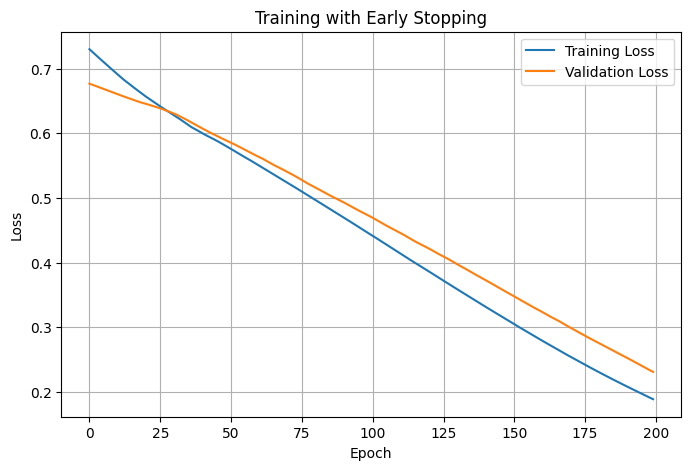

In [9]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training with Early Stopping")

plt.legend()
plt.grid()

plt.show()

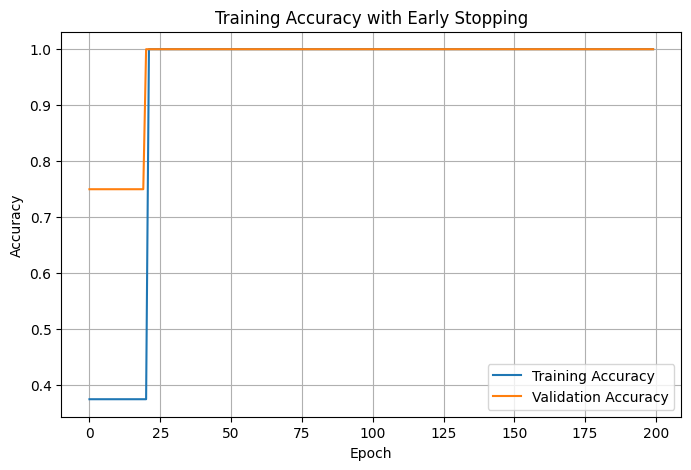

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy with Early Stopping")

plt.legend()
plt.grid()

plt.show()

In [11]:
print("Training stopped after", len(history.history["loss"]), "epochs")

Training stopped after 200 epochs


In [12]:
import pandas as pd

comparison = pd.DataFrame({
    "Training Method": [
        "Fixed Epochs",
        "Early Stopping"
    ],
    "Training Stops": [
        "After all epochs",
        "Automatically"
    ],
    "Risk of Overfitting": [
        "Higher",
        "Lower"
    ]
})

comparison

,Training Method,Training Stops,Risk of Overfitting
0,Fixed Epochs,After all epochs,Higher
1,Early Stopping,Automatically,Lower


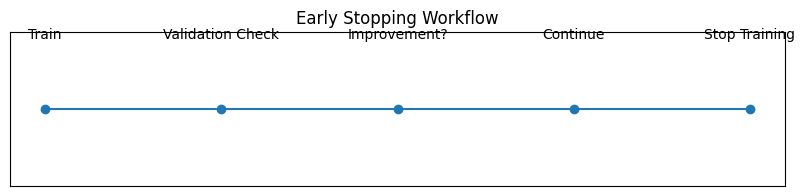

In [13]:
steps = [
    "Train",
    "Validation Check",
    "Improvement?",
    "Continue",
    "Stop Training"
]

plt.figure(figsize=(10,2))

plt.plot(range(len(steps)), [1]*len(steps), marker="o")

for i, step in enumerate(steps):
    plt.text(i, 1.05, step, ha="center")

plt.xticks([])
plt.yticks([])

plt.title("Early Stopping Workflow")

plt.show()